In [1]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DATASET 4
# =========================

DATASET_ID = 4

BASE_DIR_4 = Path(".")   # IMPORTANT : on est déjà dans dataset4

FEATURES_PKL_4 = BASE_DIR_4 / "pdfFeatures4.pkl"
TIMESERIES_PKL_4 = BASE_DIR_4 / "pdfTimeSeries4.pkl"

print("Dossier courant :", Path.cwd())
print("Features 4 :", FEATURES_PKL_4)
print("TimeSeries 4 :", TIMESERIES_PKL_4)

Dossier courant : c:\Users\user\Documents\ST4\dataset4
Features 4 : pdfFeatures4.pkl
TimeSeries 4 : pdfTimeSeries4.pkl


In [2]:
# =========================
# CHARGEMENT TIMESERIES 4
# =========================

with open(TIMESERIES_PKL_4, "rb") as f:
    pdfTimeSeries_4 = pickle.load(f)

print("pdfTimeSeries 4 chargées")
print(type(pdfTimeSeries_4))

pdfTimeSeries 4 chargées
<class 'pandas.core.frame.DataFrame'>


C:\Users\user\AppData\Local\Temp\ipykernel_5532\986776234.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  pdfTimeSeries_4 = pickle.load(f)


In [3]:
# =========================
# CHARGEMENT FEATURES 4
# =========================

with open(FEATURES_PKL_4, "rb") as f:
    features_4 = pickle.load(f)

print("Features 4 chargées")
print(type(features_4))

Features 4 chargées
<class 'pandas.core.frame.DataFrame'>


In [4]:
# Compter les identifiants disponibles
identifiants_4 = pdfTimeSeries_4["i"].unique()

print("Nombre d'identifiants :", len(identifiants_4))
print("Quelques identifiants :", identifiants_4[:10])

# Choisir automatiquement le premier identifiant disponible
# Tu peux remplacer cette ligne par un identifiant précis si tu veux en visualiser un autre.
identifiant_4 = identifiants_4[0]

print("Identifiant choisi :", identifiant_4)

Nombre d'identifiants : 315
Quelques identifiants : ['CNZQ0HOGP' 'RXV8K4NGS' 'RY3QHVKJ3' '7QBB514C2' 'T31OU6D0R' 'XKEAGD2SO'
 'N3I95AF9M' '3GW7W9V5H' 'QUTAXES28' '65TZ5MVEH']
Identifiant choisi : CNZQ0HOGP


In [5]:
# Filtrer la time series de cet identifiant
df_ts_4 = pdfTimeSeries_4[pdfTimeSeries_4["i"] == identifiant_4].copy()

display(df_ts_4.head())
print("Nombre de points :", len(df_ts_4))

,u,y,i,e
0,0.0,0.127770,CNZQ0HOGP,0.127770
1,0.0,0.024530,CNZQ0HOGP,0.024530
2,0.0,-0.036451,CNZQ0HOGP,-0.036451
3,0.0,0.053839,CNZQ0HOGP,0.053839
4,0.0,0.064586,CNZQ0HOGP,0.064586


Nombre de points : 1699


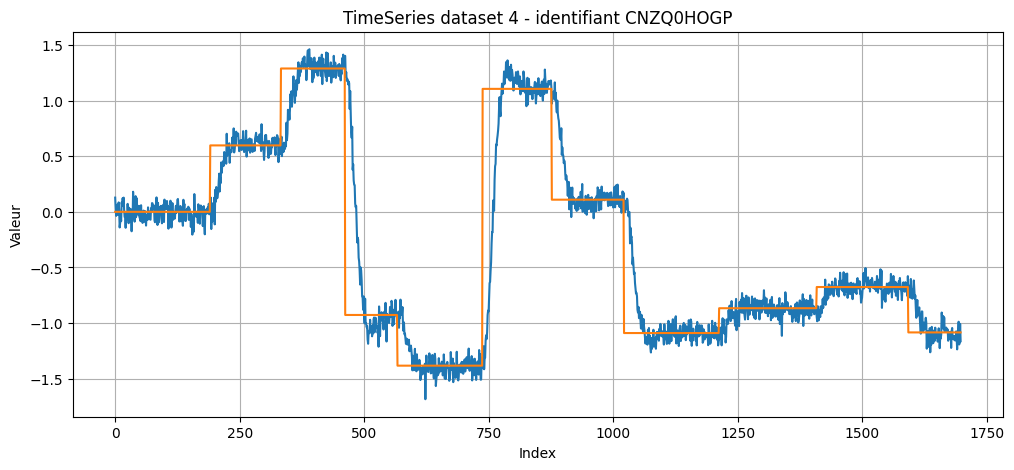

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(df_ts_4.index, df_ts_4["y"], label="Sortie y")
plt.plot(df_ts_4.index, df_ts_4["u"], label="Entrée u")

plt.xlabel("Index")
plt.ylabel("Valeur")
plt.title(f"TimeSeries dataset 4 - identifiant {identifiant_4}")
plt.grid(True)
plt.show()

In [7]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()

# Si on est dans ST4/dataset4, le projet est le dossier parent ST4
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name in ["dataset0", "dataset1", "dataset2", "dataset3", "dataset4"] else CURRENT_DIR

DATASET0_DIR = PROJECT_DIR / "dataset0"
DATASET4_DIR = PROJECT_DIR / "dataset4"

print("CURRENT_DIR  =", CURRENT_DIR)
print("PROJECT_DIR  =", PROJECT_DIR)
print("DATASET0_DIR =", DATASET0_DIR)
print("DATASET4_DIR =", DATASET4_DIR)

# Chargement du modèle normal appris sur dataset0
model_path = DATASET0_DIR / "kde_model_dataset0.pkl"

with open(model_path, "rb") as f:
    model_artifacts = pickle.load(f)

feature_columns = model_artifacts["feature_columns"]
feature_medians = model_artifacts["feature_medians"]
scaler = model_artifacts["scaler"]
pca = model_artifacts["pca"]
kde = model_artifacts["kde"]
threshold = model_artifacts["threshold"]
alpha = model_artifacts.get("alpha", None)
bandwidth = model_artifacts.get("bandwidth", None)
X_kde_sample = model_artifacts.get("X_kde_sample", None)

# Seuil identifiant appris sur dataset0 :
# un identifiant est normal si son % de fenêtres KDE anormales est <= ce seuil.
seuil_id_normal_dataset0 = model_artifacts["seuil_id_normal_dataset0"]
id_threshold_quantile = model_artifacts.get("id_threshold_quantile", 0.97)

print("Modèle dataset0 chargé")
print("Nombre de features attendues :", len(feature_columns))
print("Seuil KDE fenêtre :", threshold)
print("Alpha :", alpha)
print("Bandwidth :", bandwidth)
print("Quantile seuil identifiant :", id_threshold_quantile)
print("Seuil identifiant normal dataset0 :", seuil_id_normal_dataset0, "%")

CURRENT_DIR  = c:\Users\user\Documents\ST4\dataset4
PROJECT_DIR  = c:\Users\user\Documents\ST4
DATASET0_DIR = c:\Users\user\Documents\ST4\dataset0
DATASET4_DIR = c:\Users\user\Documents\ST4\dataset4
Modèle dataset0 chargé
Nombre de features attendues : 246
Seuil KDE fenêtre : -14.004802100248469
Alpha : 0.05
Bandwidth : 2.5
Quantile seuil identifiant : 0.97
Seuil identifiant normal dataset0 : 7.521618903971845 %


In [8]:
# Même cleaning que dataset0, mais avec les colonnes apprises sur dataset0

df_dataset4 = features_4.copy()

X_dataset4 = df_dataset4.drop(columns=["i"], errors="ignore")
X_dataset4 = X_dataset4.apply(pd.to_numeric, errors="coerce")
X_dataset4 = X_dataset4.replace([np.inf, -np.inf], np.nan)

# Très important : on force exactement les mêmes colonnes que dataset0
X_dataset4 = X_dataset4.reindex(columns=feature_columns)

# Très important : on remplit avec les médianes apprises sur dataset0
X_dataset4 = X_dataset4.fillna(feature_medians)

print("Shape dataset4 après alignement :", X_dataset4.shape)
print("Nombre de NaN restants :", X_dataset4.isna().sum().sum())
print("Nombre de valeurs infinies :", np.isinf(X_dataset4.to_numpy()).sum())

Shape dataset4 après alignement : (78243, 246)
Nombre de NaN restants : 0
Nombre de valeurs infinies : 0


In [9]:
X_dataset4_scaled = scaler.transform(X_dataset4)

finite_values = X_dataset4_scaled[np.isfinite(X_dataset4_scaled)]

max_finite = np.max(finite_values)
min_finite = np.min(finite_values)

X_dataset4_scaled = np.nan_to_num(
    X_dataset4_scaled,
    nan=0.0,
    posinf=max_finite,
    neginf=min_finite
)

X_dataset4_pca = pca.transform(X_dataset4_scaled)

print("Projection PCA dataset4 terminée")
print("Shape PCA dataset4 :", X_dataset4_pca.shape)

Projection PCA dataset4 terminée
Shape PCA dataset4 : (78243, 2)


In [10]:
# Score KDE avec le modèle normal dataset0

kde_score_dataset4 = kde.score_samples(X_dataset4_pca)

# Une fenêtre est anormale si son score KDE est inférieur au seuil appris sur dataset0
outlier_dataset4 = kde_score_dataset4 < threshold

df_dataset4_result = df_dataset4.copy()

df_dataset4_result["PCA1"] = X_dataset4_pca[:, 0]
df_dataset4_result["PCA2"] = X_dataset4_pca[:, 1]
df_dataset4_result["kde_score"] = kde_score_dataset4
df_dataset4_result["outlier"] = outlier_dataset4
df_dataset4_result["is_normal_window"] = ~outlier_dataset4

print("Nombre total de fenêtres dataset4 :", len(df_dataset4_result))
print("Fenêtres détectées anormales :", df_dataset4_result["outlier"].sum())
print("Pourcentage fenêtres anormales :", round(100 * df_dataset4_result["outlier"].mean(), 2), "%")

Nombre total de fenêtres dataset4 : 78243
Fenêtres détectées anormales : 5957
Pourcentage fenêtres anormales : 7.61 %


In [11]:
# Résumé par identifiant dataset4
# Ici, la décision normal/défaut général utilise seulement le % de fenêtres KDE anormales.

summary_dataset4 = (
    df_dataset4_result
    .groupby("i")
    .agg(
        nb_windows=("outlier", "size"),
        nb_windows_anormales=("outlier", "sum"),
        pct_windows_anormales=("outlier", lambda x: 100 * x.mean()),
        kde_score_mean=("kde_score", "mean"),
        kde_score_min=("kde_score", "min"),
    )
    .reset_index()
)

summary_dataset4["id_normal_dataset0"] = (
    summary_dataset4["pct_windows_anormales"] <= seuil_id_normal_dataset0
)

summary_dataset4["classe_predite_dataset0"] = np.where(
    summary_dataset4["id_normal_dataset0"],
    "normal",
    "defaut"
)

nb_total = len(summary_dataset4)
nb_normaux = summary_dataset4["id_normal_dataset0"].sum()
nb_defauts = nb_total - nb_normaux

print("Résultat dataset4 avec le modèle normal dataset0 :")
print("Seuil accepté pour un identifiant normal :", seuil_id_normal_dataset0, "%")
print("Identifiants normaux :", nb_normaux)
print("Identifiants défauts :", nb_defauts)
print("Total :", nb_total)
print("Pourcentage normaux :", round(100 * nb_normaux / nb_total, 2), "%")
print("Pourcentage défauts :", round(100 * nb_defauts / nb_total, 2), "%")

display(
    summary_dataset4
    .sort_values("pct_windows_anormales", ascending=False)
)

Résultat dataset4 avec le modèle normal dataset0 :
Seuil accepté pour un identifiant normal : 7.521618903971845 %
Identifiants normaux : 150
Identifiants défauts : 165
Total : 315
Pourcentage normaux : 47.62 %
Pourcentage défauts : 52.38 %


,i,nb_windows,nb_windows_anormales,pct_windows_anormales,kde_score_mean,kde_score_min,id_normal_dataset0,classe_predite_dataset0
135,GF6D3XQRV,189,45,23.809524,-94.393997,-15158.250488,False,defaut
27,2RGNKV1S3,164,36,21.951220,-216.509226,-32018.036055,False,defaut
296,XPUY2MMNE,172,34,19.767442,-37.641178,-2137.385961,False,defaut
79,9MIT9X5LV,191,37,19.371728,-42.728210,-6309.166552,False,defaut
161,JL1VZK8NM,163,31,19.018405,-13.943857,-584.765315,False,defaut
...,...,...,...,...,...,...,...,...
220,QUTAXES28,233,3,1.287554,-5.336875,-21.852090,True,normal
136,GHXSZMA7S,236,3,1.271186,-5.846286,-21.035420,True,normal
132,FYIVP8OOP,322,4,1.242236,-5.802914,-36.714162,True,normal
231,RXV8K4NGS,252,3,1.190476,-5.028706,-16.933471,True,normal
